In [17]:
from data import get_etf_prices, get_stock_prices, get_returns, get_summary
from portfolio import get_optimal_weights
from backtest import backtest_monthly, get_performance
from tax import get_tax_report
from report import generate_report
from visualize import (plot_cumulative_returns, plot_backtest, 
                       plot_comparison, plot_weights, plot_monthly_comparison)
from config import STOCKS, ETF_WEIGHTS, RISK_PROFILE

In [18]:
etf_prices = get_etf_prices()
stock_prices = get_stock_prices()

[*********************100%***********************]  4 of 4 completed


ETF 데이터 로드 완료: 1595일치, 2020-01-01~현재


[*********************100%***********************]  7 of 7 completed

주식 데이터 로드 완료: 1595일치, 2020-01-01~현재


In [19]:
print("=== ETF 요약 ===")
print(get_summary(etf_prices))

=== ETF 요약 ===
       연평균 수익률  연간 변동성
Ticker                
BND      1.07%   6.54%
QQQ     22.18%  24.98%
SCHD    13.06%  19.03%
SPY     16.35%  20.43%


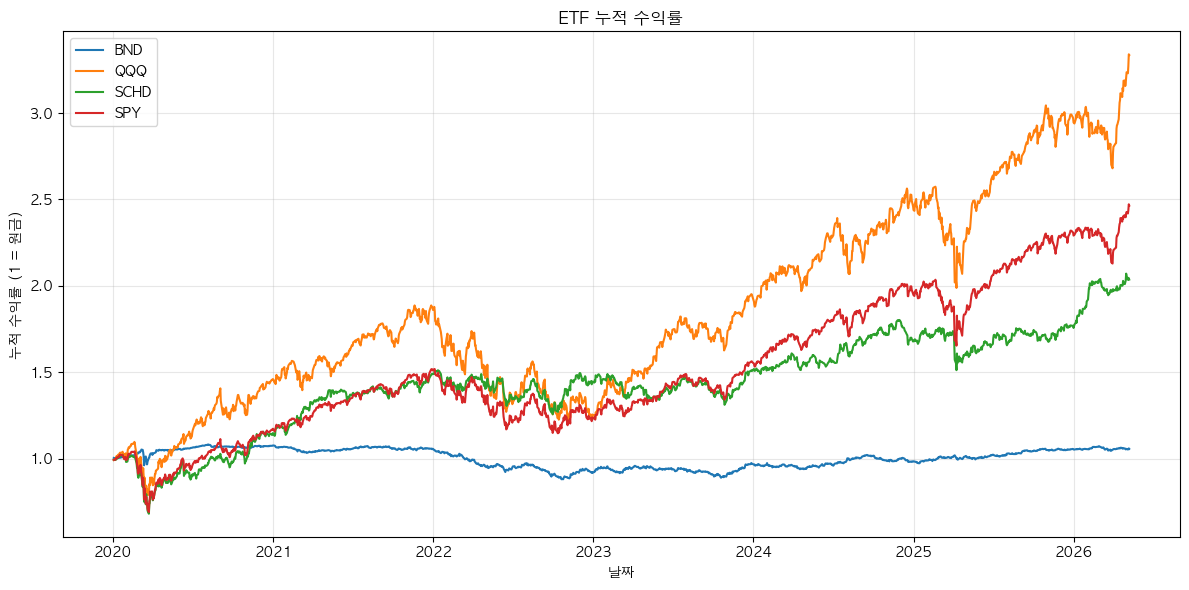

In [20]:
plot_cumulative_returns(etf_prices)

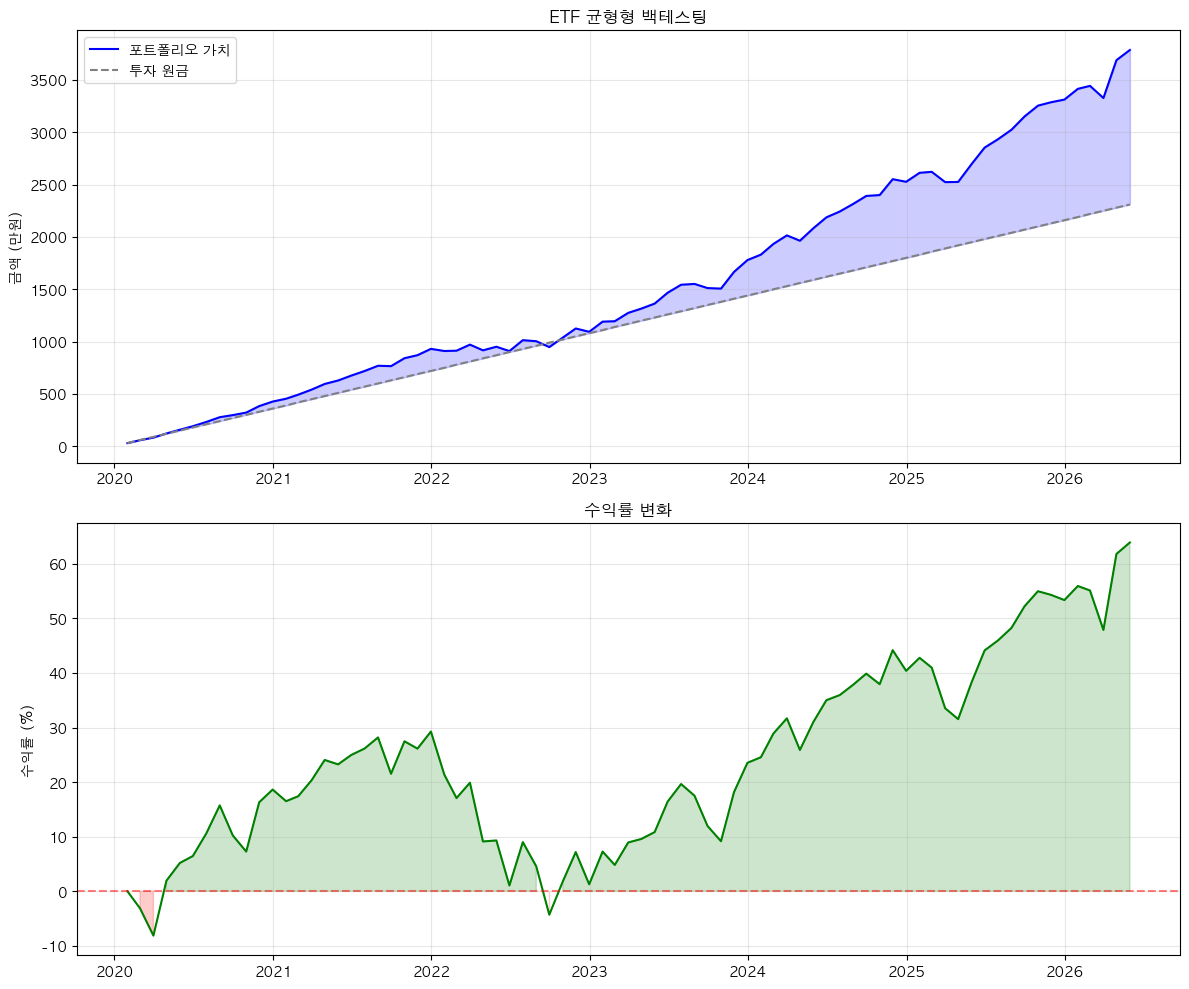

In [21]:
etf_weights = ETF_WEIGHTS[RISK_PROFILE]
etf_result = backtest_monthly(etf_prices, etf_weights)
plot_backtest(etf_result, 'ETF 균형형 백테스팅')

In [22]:
etf_perf = get_performance(etf_result)
etf_tax = get_tax_report(etf_perf)

총 투자 원금                   2,310만원
세전 최종 자산                  3,786만원
총 수익                      1,476만원
수익률                  63.91
샤프 비율                1.85
MDD                  -6.54
일반 계좌 세금                    270만원
ISA 계좌 세금                   126만원
일반 계좌 세후 자산               3,517만원
ISA 계좌 세후 자산              3,660만원
ISA 절세 효과                   143만원


       최소분산  리스크패리티   블렌딩
AAPL   25.2    17.2  21.2
NVDA    5.7    15.4  10.5
MSFT   20.5    16.8  18.6
AMZN    5.0    13.0   9.0
GOOGL  33.7    17.3  25.5
META    5.0    10.4   7.7
TSLA    5.0     9.9   7.5


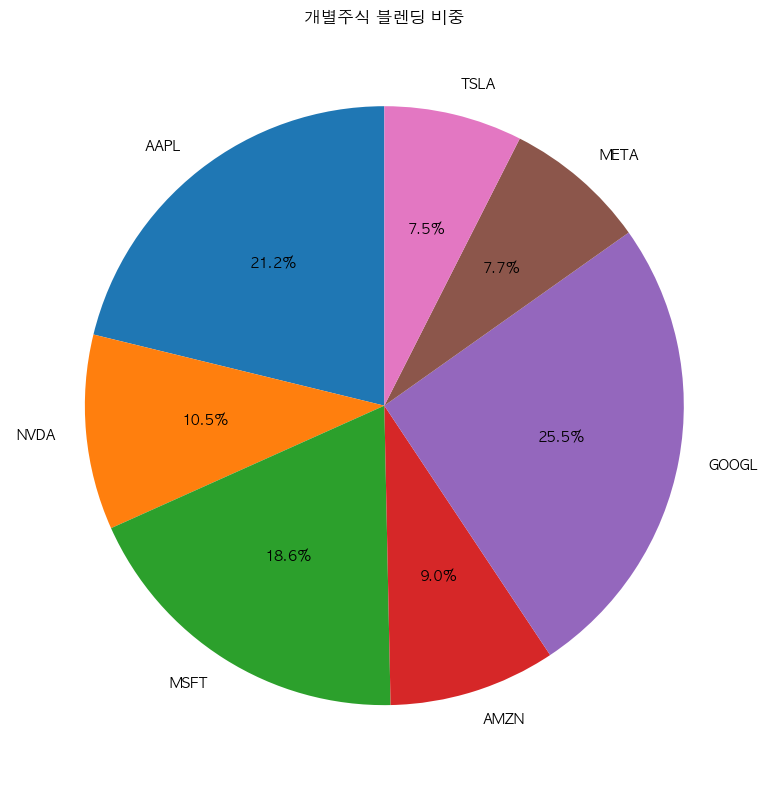

In [23]:
stock_returns = get_returns(stock_prices)
blend, weight_table = get_optimal_weights(stock_returns)
print(weight_table)
plot_weights(blend, STOCKS, '개별주식 블렌딩 비중')

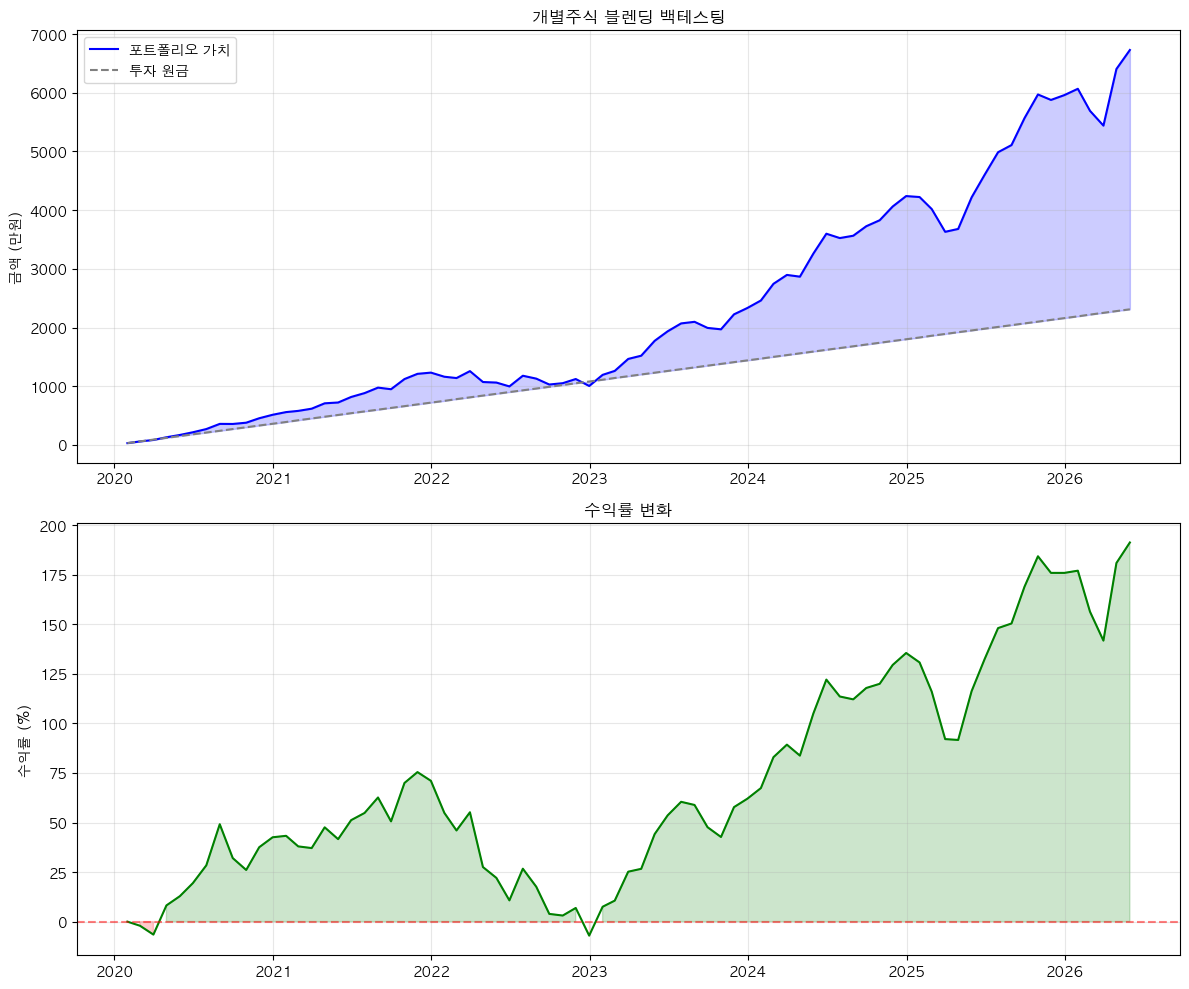

In [24]:
stock_weights = dict(zip(STOCKS, blend))
stock_result = backtest_monthly(stock_prices, stock_weights)
plot_backtest(stock_result, '개별주식 블렌딩 백테스팅')

In [25]:
stock_perf = get_performance(stock_result)
stock_tax = get_tax_report(stock_perf)

총 투자 원금                   2,310만원
세전 최종 자산                  6,729만원
총 수익                      4,419만원
수익률                  191.30
샤프 비율                1.86
MDD                  -20.72
일반 계좌 세금                    917만원
ISA 계좌 세금                   418만원
일반 계좌 세후 자산               5,812만원
ISA 계좌 세후 자산              6,311만원
ISA 절세 효과                   499만원


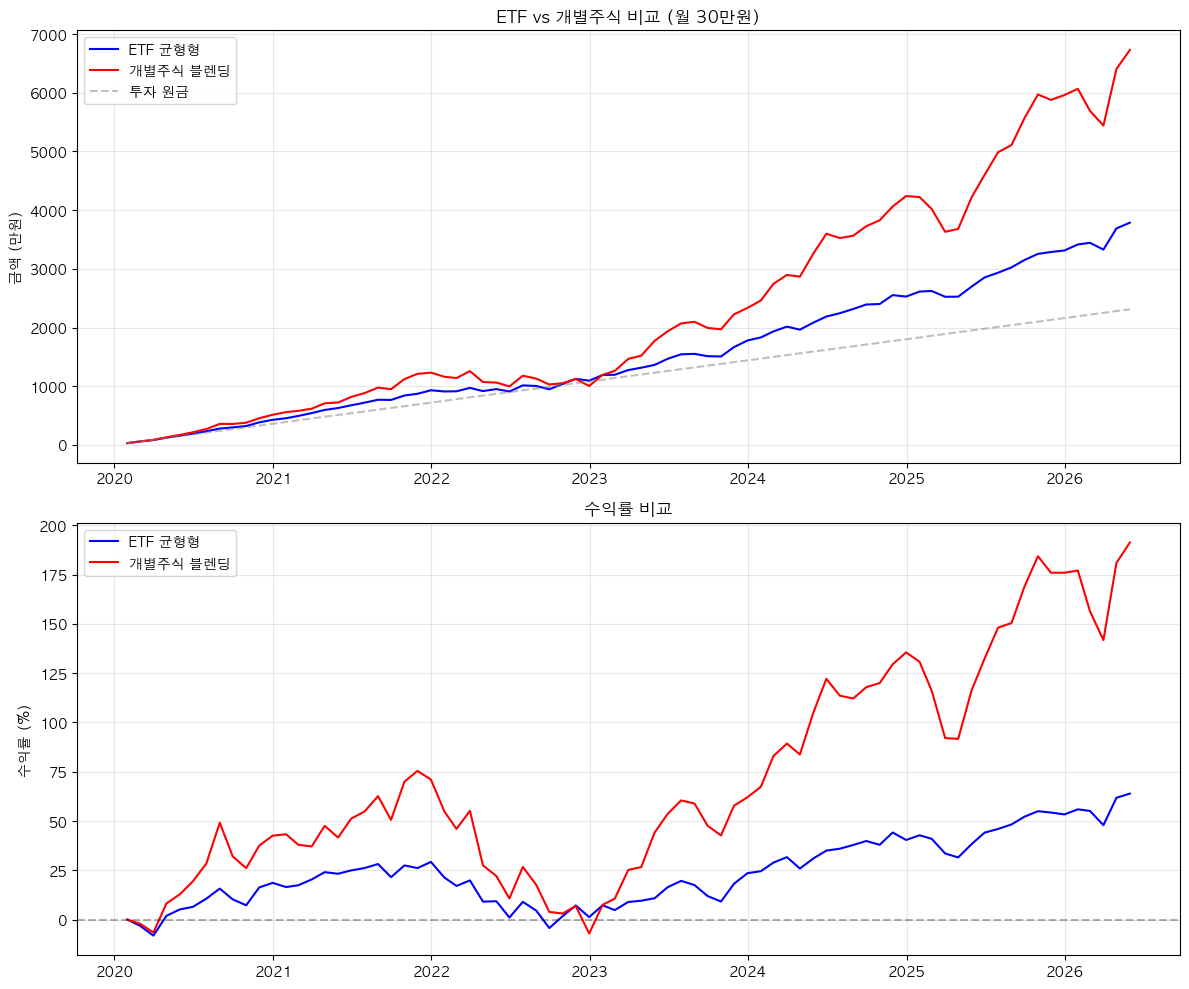

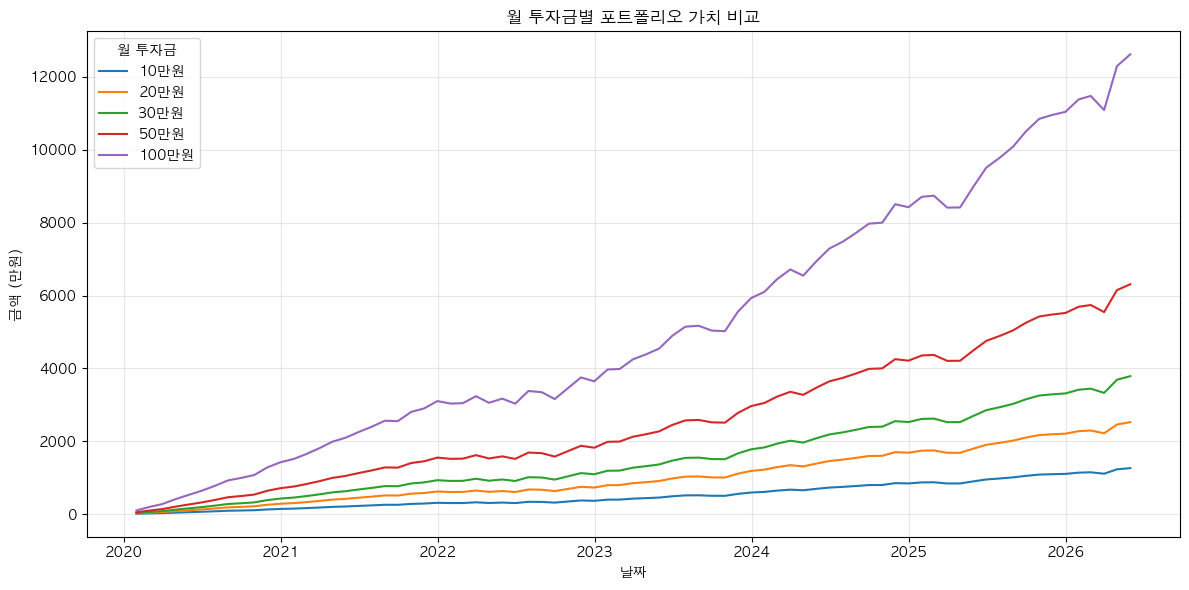

In [26]:
plot_comparison(etf_result, stock_result)
plot_monthly_comparison(etf_prices, etf_weights, 
                        [100000, 200000, 300000, 500000, 1000000])

In [27]:
from portfolio import momentum_weights, market_cap_weights

# 모멘텀 전략 (최근 6개월 수익이 음수이면 0% 간주)
momentum_w = momentum_weights(stock_prices)
momentum_weights_dict = dict(zip(STOCKS, momentum_w))
print("=== 모멘텀 비중 ===")
for t, w in zip(STOCKS, momentum_w):
    print(f"{t}: {w*100:.1f}%")

# 시가총액 비중
print("\n=== 시가총액 비중 ===")
mcap_w = market_cap_weights(STOCKS)
mcap_weights_dict = dict(zip(STOCKS, mcap_w))
for t, w in zip(STOCKS, mcap_w):
    print(f"{t}: {w*100:.1f}%")

=== 모멘텀 비중 ===
AAPL: 10.4%
NVDA: 13.2%
MSFT: 63.2%
AMZN: 0.0%
GOOGL: 0.0%
META: 13.2%
TSLA: 0.0%

=== 시가총액 비중 ===
AAPL: 4.22조 달러
NVDA: 5.14조 달러
MSFT: 3.13조 달러
AMZN: 2.92조 달러
GOOGL: 4.82조 달러
META: 1.57조 달러
TSLA: 1.55조 달러
AAPL: 18.1%
NVDA: 22.0%
MSFT: 13.4%
AMZN: 12.5%
GOOGL: 20.7%
META: 6.7%
TSLA: 6.6%


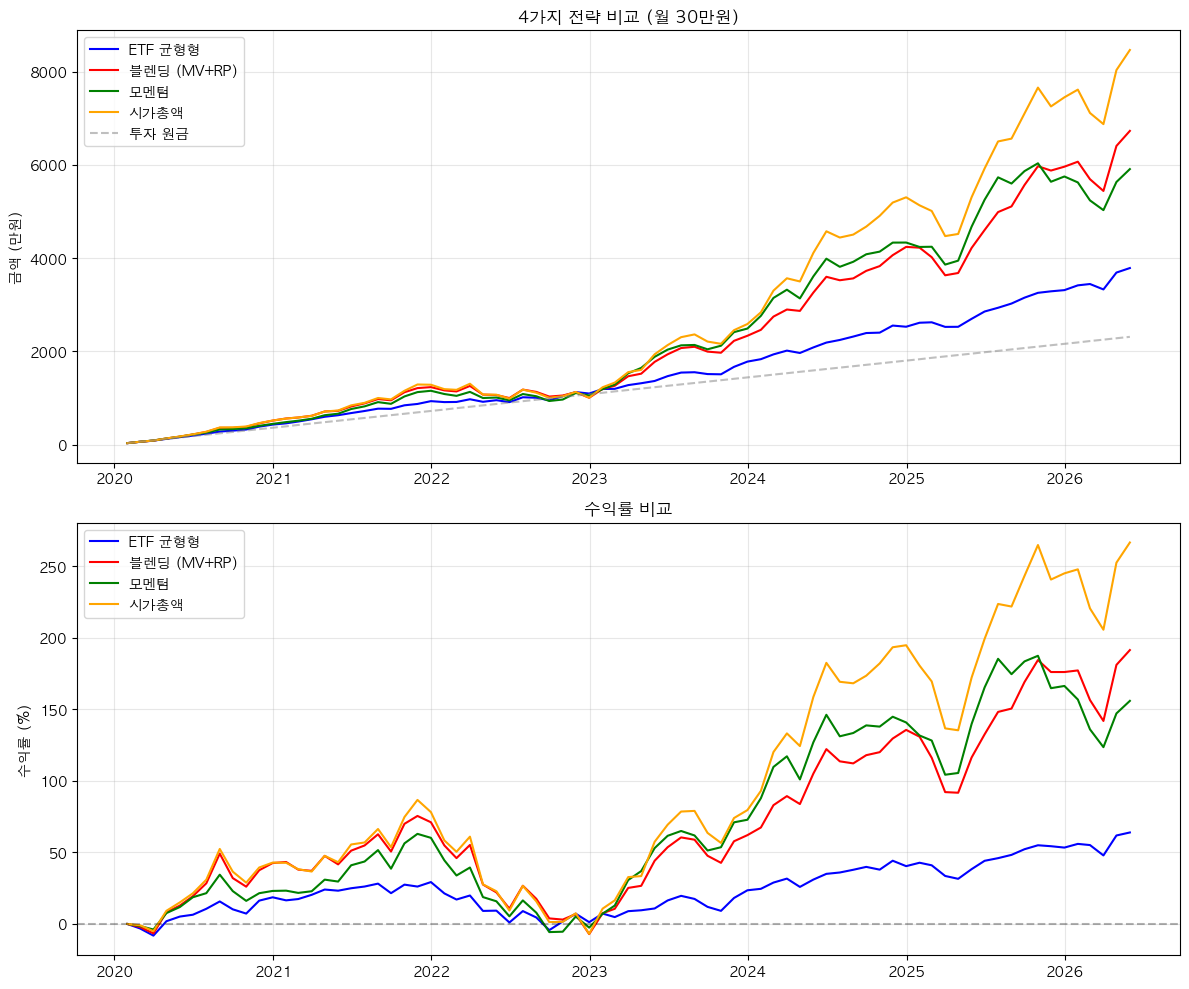

In [28]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 네 가지 전략 백테스팅
momentum_result = backtest_monthly(stock_prices, momentum_weights_dict)
mcap_result = backtest_monthly(stock_prices, mcap_weights_dict)

# 비교 그래프
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

strategies = {
    'ETF 균형형': etf_result,
    '블렌딩 (MV+RP)': stock_result,
    '모멘텀': momentum_result,
    '시가총액': mcap_result,
}
colors = ['blue', 'red', 'green', 'orange']

for (name, r), color in zip(strategies.items(), colors):
    ax1.plot(r.index, r['포트폴리오 가치']/10000, label=name, color=color)
    profit_rate = (r['포트폴리오 가치'] / r['투자 원금'] - 1) * 100
    ax2.plot(r.index, profit_rate, label=name, color=color)

ax1.plot(etf_result.index, etf_result['투자 원금']/10000,
         '--', color='gray', label='투자 원금', alpha=0.5)
ax1.set_title('4가지 전략 비교 (월 30만원)')
ax1.set_ylabel('금액 (만원)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('수익률 비교')
ax2.set_ylabel('수익률 (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

# 네 가지 전략 성과 지표 비교
strategies_result = {
    'ETF 균형형': etf_result,
    '블렌딩 (MV+RP)': stock_result,
    '모멘텀': momentum_result,
    '시가총액': mcap_result,
}

comparison = []
for name, r in strategies_result.items():
    perf = get_performance(r)
    comparison.append({
        '전략': name,
        '수익률(%)': round(perf['수익률'], 1),
        '샤프 비율': perf['샤프 비율'],
        'MDD(%)': perf['MDD'],
    })

comparison_df = pd.DataFrame(comparison).set_index('전략')
print(comparison_df)

             수익률(%)  샤프 비율  MDD(%)
전략                                
ETF 균형형        63.9   1.85   -6.54
블렌딩 (MV+RP)   191.3   1.86  -20.72
모멘텀           155.8   1.84  -19.01
시가총액          266.4   1.88  -24.49


In [30]:
report = generate_report(etf_tax, stock_tax, blend, STOCKS, comparison_df)
print(report)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [31]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 다운로드
tickers = ["NVO", "VOO"]
data = yf.download(tickers, start="2020-01-01")
prices = data["Close"].dropna()

print(prices.tail())
print(f"\n데이터 크기: {prices.shape}")

[*********************100%***********************]  2 of 2 completed

Ticker            NVO         VOO
Date                             
2026-05-01  43.880001  662.520020
2026-05-04  44.389999  660.119995
2026-05-05  44.869999  665.299988
2026-05-06  45.759998  674.659973
2026-05-07  45.799999  672.539978

데이터 크기: (1595, 2)


In [32]:
# 2020년부터 필터링
prices = prices[prices.index >= "2020-01-01"]

# 일별 투자 백테스팅 (전략 A, B)
def backtest_daily(prices, ticker, daily_amount=1000):
    price_series = prices[ticker]
    
    shares = 0
    invested = 0
    portfolio_value = []
    total_invested = []
    
    for date, price in price_series.items():
        shares += daily_amount / price
        invested += daily_amount
        portfolio_value.append(shares * price)
        total_invested.append(invested)
    
    result = pd.DataFrame({
        '포트폴리오 가치': portfolio_value,
        '투자 원금': total_invested
    }, index=price_series.index)
    
    return result

# 월별 투자 백테스팅 (전략 C, D)
def backtest_monthly_single(prices, ticker, monthly_amount=20000):
    price_series = prices[ticker].resample('ME').last().dropna()
    
    shares = 0
    invested = 0
    portfolio_value = []
    total_invested = []
    
    for date, price in price_series.items():
        shares += monthly_amount / price
        invested += monthly_amount
        portfolio_value.append(shares * price)
        total_invested.append(invested)
    
    result = pd.DataFrame({
        '포트폴리오 가치': portfolio_value,
        '투자 원금': total_invested
    }, index=price_series.index)
    
    return result

# 네 가지 전략 백테스팅
result_a = backtest_daily(prices, "NVO", daily_amount=1000)
result_b = backtest_daily(prices, "VOO", daily_amount=1000)
result_c = backtest_monthly_single(prices, "NVO", monthly_amount=20000)
result_d = backtest_monthly_single(prices, "VOO", monthly_amount=20000)

print("전략 A (매일 NVO):", f"{result_a['포트폴리오 가치'].iloc[-1]/10000:.1f}만원")
print("전략 B (매일 VOO):", f"{result_b['포트폴리오 가치'].iloc[-1]/10000:.1f}만원")
print("전략 C (매월 NVO):", f"{result_c['포트폴리오 가치'].iloc[-1]/10000:.1f}만원")
print("전략 D (매월 VOO):", f"{result_d['포트폴리오 가치'].iloc[-1]/10000:.1f}만원")

전략 A (매일 NVO): 147.6만원
전략 B (매일 VOO): 276.6만원
전략 C (매월 NVO): 142.7만원
전략 D (매월 VOO): 264.8만원


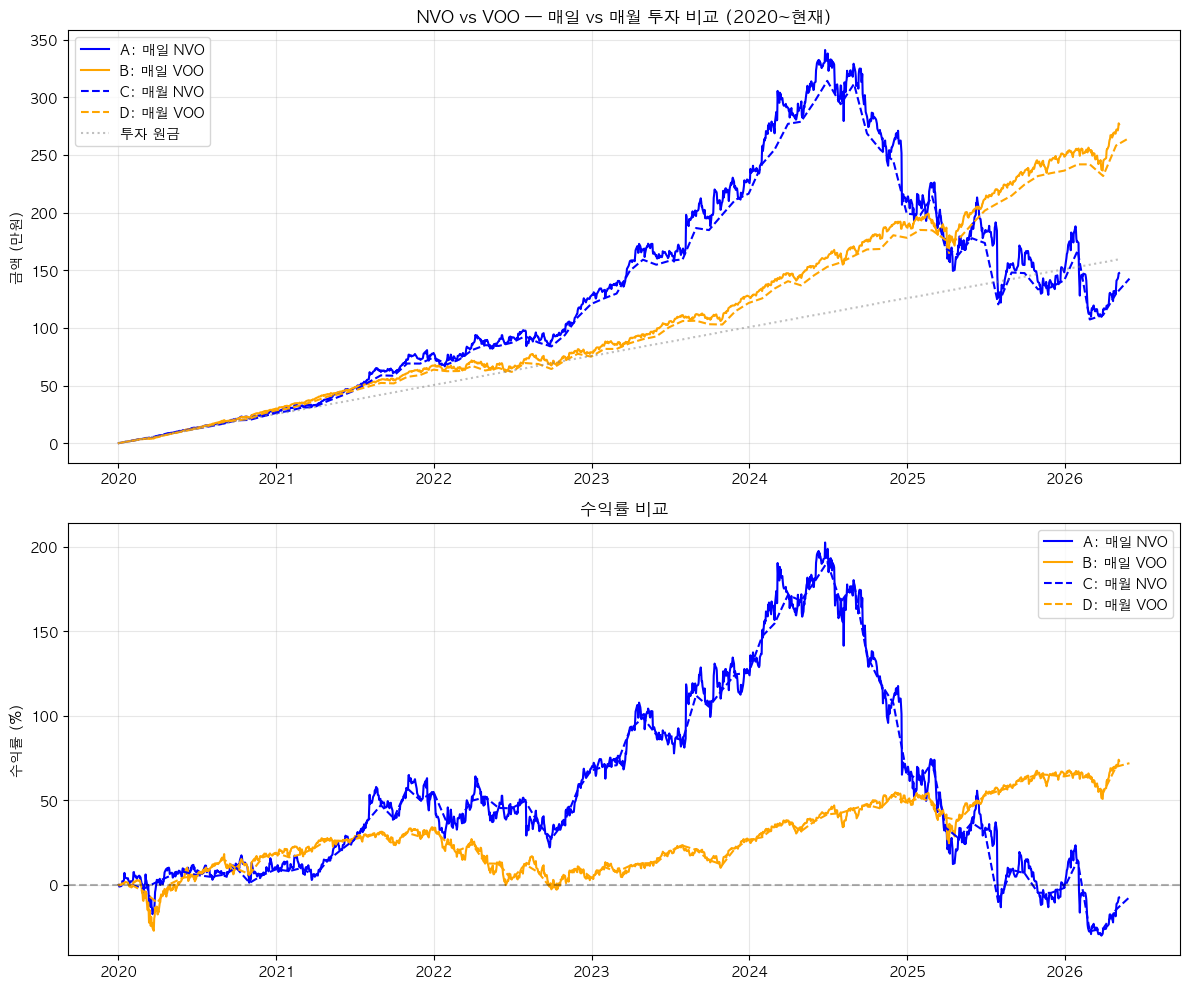

In [34]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 상단: 포트폴리오 가치
ax1.plot(result_a.index, result_a['포트폴리오 가치']/10000, label='A: 매일 NVO', color='blue')
ax1.plot(result_b.index, result_b['포트폴리오 가치']/10000, label='B: 매일 VOO', color='orange')
ax1.plot(result_c.index, result_c['포트폴리오 가치']/10000, label='C: 매월 NVO', color='blue', linestyle='--')
ax1.plot(result_d.index, result_d['포트폴리오 가치']/10000, label='D: 매월 VOO', color='orange', linestyle='--')
ax1.plot(result_a.index, result_a['투자 원금']/10000, color='gray', linestyle=':', label='투자 원금', alpha=0.5)
ax1.set_title('NVO vs VOO — 매일 vs 매월 투자 비교 (2020~현재)')
ax1.set_ylabel('금액 (만원)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 하단: 수익률
for result, label, color, ls in [
    (result_a, 'A: 매일 NVO', 'blue', '-'),
    (result_b, 'B: 매일 VOO', 'orange', '-'),
    (result_c, 'C: 매월 NVO', 'blue', '--'),
    (result_d, 'D: 매월 VOO', 'orange', '--'),
]:
    profit = (result['포트폴리오 가치'] / result['투자 원금'] - 1) * 100
    ax2.plot(result.index, profit, label=label, color=color, linestyle=ls)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('수익률 비교')
ax2.set_ylabel('수익률 (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
import yfinance as yf

# NVO 관련 최신 뉴스 가져오기
nvo = yf.Ticker("NVO")
news = nvo.news

for i, article in enumerate(news[:5]):
    print(f"[{i+1}] {article['content']['title']}")
    print(f"    {article['content']['pubDate']}")
    print()

[1] Earnings live updates: Airbnb raises revenue forecast, even as Iran war weighs on some markets
    2026-05-04T10:00:00Z

[2] Is Novo Nordisk (NYSE:NVO) Pricing Look Interesting After Recent Share Price Rebound?
    2026-05-08T01:21:11Z

[3] A Look At Novo Nordisk (CPSE:NOVO B) Valuation After Oral Wegovy Success Lifts 2026 Outlook
    2026-05-07T22:20:11Z

[4] Novo Nordisk Surges 9.2% As Wegovy Pill Fuels Momentum
    2026-05-07T18:39:56Z

[5] Forget Eli Lilly: These 2 Stocks Have More Upside
    2026-05-07T18:35:00Z



In [ ]:
import os
os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"
from groq import Groq
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))


client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def analyze_sentiment(title):
    """뉴스 제목 감성 분석"""
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{
            "role": "user",
            "content": f"""다음 뉴스 제목을 분석해서 NVO(노보노디스크) 주가에 미치는 영향을 평가해줘.
            
뉴스: {title}

아래 JSON 형식으로만 답해줘. 다른 말은 하지 마:
{{"score": -1 ~ 1 사이 숫자, "reason": "한 문장 이유"}}"""
        }]
    )
    import json
    text = response.choices[0].message.content.strip()
    # ```json 같은 마크다운 제거
    text = text.replace("```json", "").replace("```", "").strip()
    try:
        return json.loads(text)
    except:
        return {"score": 0.0, "reason": "분석 실패"}

# 뉴스 감성 분석
print("=== NVO 뉴스 감성 분석 ===\n")
scores = []
for article in news[:5]:
    title = article['content']['title']
    result = analyze_sentiment(title)
    scores.append(result['score'])
    sentiment = "🟢 긍정" if result['score'] > 0 else "🔴 부정" if result['score'] < 0 else "⚪ 중립"
    print(f"{sentiment} ({result['score']:+.1f}) {title[:50]}...")
    print(f"         → {result['reason']}\n")

avg_score = sum(scores) / len(scores)
print(f"{'='*45}")
print(f"종합 감성 점수: {avg_score:+.2f}")
if avg_score > 0.2:
    print("투자 신호: 📈 매수 고려")
elif avg_score < -0.2:
    print("투자 신호: 📉 매도 고려")
else:
    print("투자 신호: ⏸ 관망")

=== NVO 뉴스 감성 분석 ===

⚪ 중립 (+0.0) Earnings live updates: Airbnb raises revenue forec...
         → 이 뉴스는 NVO(노보노디스크) 주가와 직접적인 관련이 없기 때문에 영향을 미치지 않을 것으로 판단됩니다.

🟢 긍정 (+0.5) Is Novo Nordisk (NYSE:NVO) Pricing Look Interestin...
         → NVO 주가가 최근 반등한 상황에 대해 주가가 매력적으로 보이는지 분석한 내용으로 긍정적影響 가능성이 있으나 확실하지 않다.

🟢 긍정 (+0.5) A Look At Novo Nordisk (CPSE:NOVO B) Valuation Aft...
         → Wegovy의 경구 성공으로 2026년 전망이 개선됨에 따라 노보노디스크의 평가가 상승할 수 있음

🟢 긍정 (+1.0) Novo Nordisk Surges 9.2% As Wegovy Pill Fuels Mome...
         → 웨고비(Wegovy) 약물로 인해 노보노디스크(Novo Nordisk)의 주가가 9.2% 상승하기 때문에

⚪ 중립 (+0.0) Forget Eli Lilly: These 2 Stocks Have More Upside...
         → 뉴스에서 NVO(노보노디스크) 주가에 직접적인 언급이나 영향력이 없기 때문입니다.

종합 감성 점수: +0.40
투자 신호: 📈 매수 고려


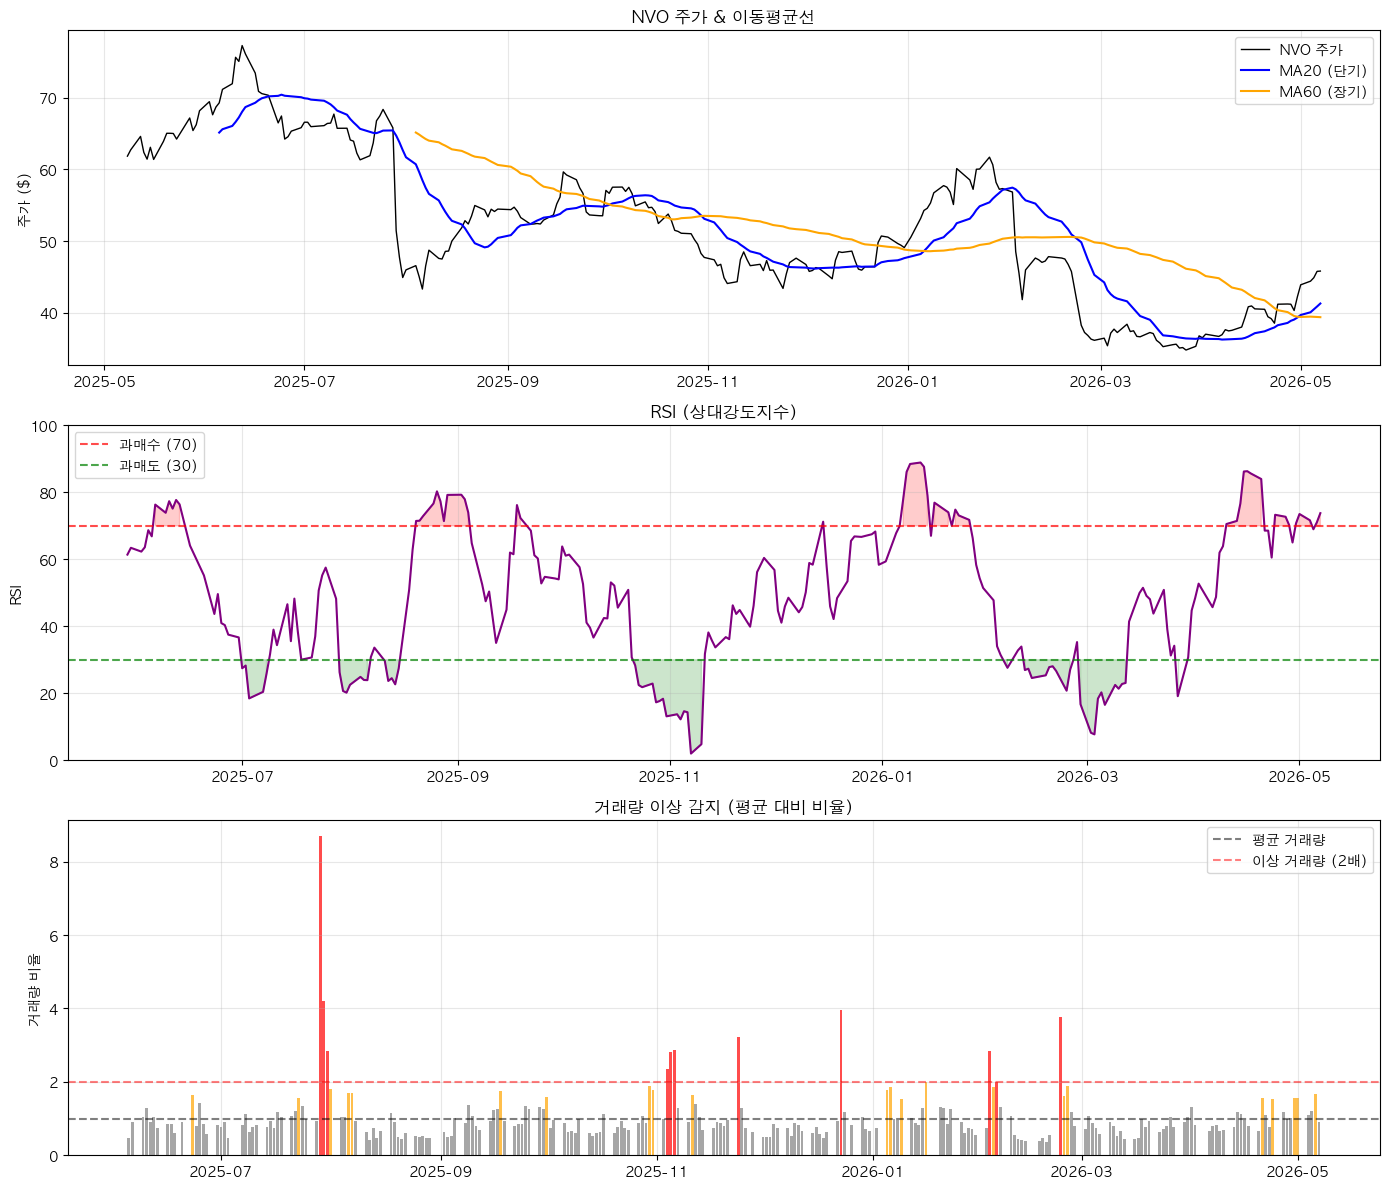

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# NVO 데이터 가져오기
nvo = yf.Ticker("NVO")
df = nvo.history(period="1y")  # 최근 1년

# ── 기술적 지표 계산 ──

# 1. 이동평균선 (MA)
df['MA20'] = df['Close'].rolling(20).mean()   # 단기
df['MA60'] = df['Close'].rolling(60).mean()   # 장기

# 2. RSI (과매수/과매도 지표)
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 3. 거래량 이상 감지
df['Volume_MA20'] = df['Volume'].rolling(20).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA20']  # 1 이상이면 평소보다 많은 거래량

# ── 시각화 ──
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# 상단: 주가 + 이동평균선
ax1.plot(df.index, df['Close'], label='NVO 주가', color='black', linewidth=1)
ax1.plot(df.index, df['MA20'], label='MA20 (단기)', color='blue', linewidth=1.5)
ax1.plot(df.index, df['MA60'], label='MA60 (장기)', color='orange', linewidth=1.5)
ax1.set_title('NVO 주가 & 이동평균선')
ax1.set_ylabel('주가 ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 중단: RSI
ax2.plot(df.index, df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='과매수 (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='과매도 (30)')
ax2.fill_between(df.index, 70, df['RSI'], where=df['RSI'] >= 70, color='red', alpha=0.2)
ax2.fill_between(df.index, 30, df['RSI'], where=df['RSI'] <= 30, color='green', alpha=0.2)
ax2.set_title('RSI (상대강도지수)')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 하단: 거래량 이상 감지
colors = ['red' if v > 2.0 else 'orange' if v > 1.5 else 'gray' 
          for v in df['Volume_Ratio']]
ax3.bar(df.index, df['Volume_Ratio'], color=colors, alpha=0.7)
ax3.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='평균 거래량')
ax3.axhline(y=2.0, color='red', linestyle='--', alpha=0.5, label='이상 거래량 (2배)')
ax3.set_title('거래량 이상 감지 (평균 대비 비율)')
ax3.set_ylabel('거래량 비율')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# 세 가지 신호 종합 매수/매도 자동화

def generate_signal(df, sentiment_score=0.0):
    """RSI + 이동평균 + 거래량 + 감성 점수 종합 신호"""
    
    latest = df.iloc[-1]
    signals = []
    scores = []
    
    # ── 1. RSI 신호 ──
    rsi = latest['RSI']
    if rsi < 30:
        signals.append(("RSI", "매수", f"RSI {rsi:.1f} — 과매도 구간"))
        scores.append(1.0)
    elif rsi > 70:
        signals.append(("RSI", "매도", f"RSI {rsi:.1f} — 과매수 구간"))
        scores.append(-1.0)
    else:
        signals.append(("RSI", "중립", f"RSI {rsi:.1f} — 중립 구간"))
        scores.append(0.0)
    
    # ── 2. 이동평균선 신호 ──
    ma20 = latest['MA20']
    ma60 = latest['MA60']
    close = latest['Close']
    if ma20 > ma60 and close > ma20:
        signals.append(("이동평균", "매수", f"골든크로스 — MA20({ma20:.1f}) > MA60({ma60:.1f})"))
        scores.append(1.0)
    elif ma20 < ma60 and close < ma20:
        signals.append(("이동평균", "매도", f"데드크로스 — MA20({ma20:.1f}) < MA60({ma60:.1f})"))
        scores.append(-1.0)
    else:
        signals.append(("이동평균", "중립", f"MA20({ma20:.1f}) vs MA60({ma60:.1f})"))
        scores.append(0.0)
    
    # ── 3. 거래량 신호 ──
    vol_ratio = latest['Volume_Ratio']
    price_change = (latest['Close'] - df.iloc[-2]['Close']) / df.iloc[-2]['Close'] * 100
    if vol_ratio > 2.0 and price_change > 0:
        signals.append(("거래량", "매수", f"거래량 {vol_ratio:.1f}배 + 주가 상승 — 강한 매수세"))
        scores.append(1.0)
    elif vol_ratio > 2.0 and price_change < 0:
        signals.append(("거래량", "매도", f"거래량 {vol_ratio:.1f}배 + 주가 하락 — 강한 매도세"))
        scores.append(-1.0)
    else:
        signals.append(("거래량", "중립", f"거래량 {vol_ratio:.1f}배 — 평범한 수준"))
        scores.append(0.0)
    
    # ── 4. 뉴스 감성 신호 ──
    if sentiment_score > 0.2:
        signals.append(("뉴스 감성", "매수", f"감성 점수 {sentiment_score:+.2f} — 긍정적"))
        scores.append(1.0)
    elif sentiment_score < -0.2:
        signals.append(("뉴스 감성", "매도", f"감성 점수 {sentiment_score:+.2f} — 부정적"))
        scores.append(-1.0)
    else:
        signals.append(("뉴스 감성", "중립", f"감성 점수 {sentiment_score:+.2f} — 중립"))
        scores.append(0.0)
    
    # ── 종합 판단 ──
    final_score = sum(scores) / len(scores)
    
    print(f"{'='*50}")
    print(f"NVO 종합 투자 신호 분석 ({df.index[-1].strftime('%Y-%m-%d')})")
    print(f"{'='*50}")
    for indicator, signal, reason in signals:
        emoji = "📈" if signal == "매수" else "📉" if signal == "매도" else "⏸"
        print(f"{emoji} [{indicator}] {signal} — {reason}")
    
    print(f"\n{'─'*50}")
    print(f"종합 점수: {final_score:+.2f}")
    
    if final_score > 0.3:
        print("🟢 최종 신호: 매수 고려")
    elif final_score < -0.3:
        print("🔴 최종 신호: 매도 고려")
    else:
        print("⚪ 최종 신호: 관망")
    print(f"{'='*50}")
    
    return final_score

# 실행 (아까 뉴스 감성 점수 -0.10 반영)
final = generate_signal(df, sentiment_score=-0.10)

NVO 종합 투자 신호 분석 (2026-05-07)
📉 [RSI] 매도 — RSI 73.8 — 과매수 구간
📈 [이동평균] 매수 — 골든크로스 — MA20(41.3) > MA60(39.4)
⏸ [거래량] 중립 — 거래량 0.9배 — 평범한 수준
⏸ [뉴스 감성] 중립 — 감성 점수 -0.10 — 중립

──────────────────────────────────────────────────
종합 점수: +0.00
⚪ 최종 신호: 관망
